# Imports:

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# Datasets:

In [73]:
df_irregular = pd.read_csv("data/smell.csv")
df_regular = pd.read_csv("data/electricity.csv")

# Regular Dataset

Printing the head of the dataset

In [15]:
print(df_regular.head())

   date  day    period  nswprice  nswdemand  vicprice  vicdemand  transfer  \
0   0.0    2  0.000000  0.056443   0.439155  0.003467   0.422915  0.414912   
1   0.0    2  0.021277  0.051699   0.415055  0.003467   0.422915  0.414912   
2   0.0    2  0.042553  0.051489   0.385004  0.003467   0.422915  0.414912   
3   0.0    2  0.063830  0.045485   0.314639  0.003467   0.422915  0.414912   
4   0.0    2  0.085106  0.042482   0.251116  0.003467   0.422915  0.414912   

  class  
0    UP  
1    UP  
2    UP  
3    UP  
4  DOWN  


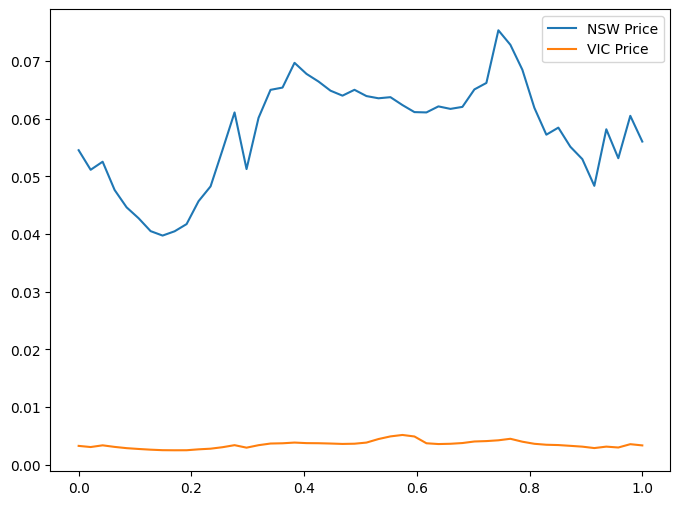

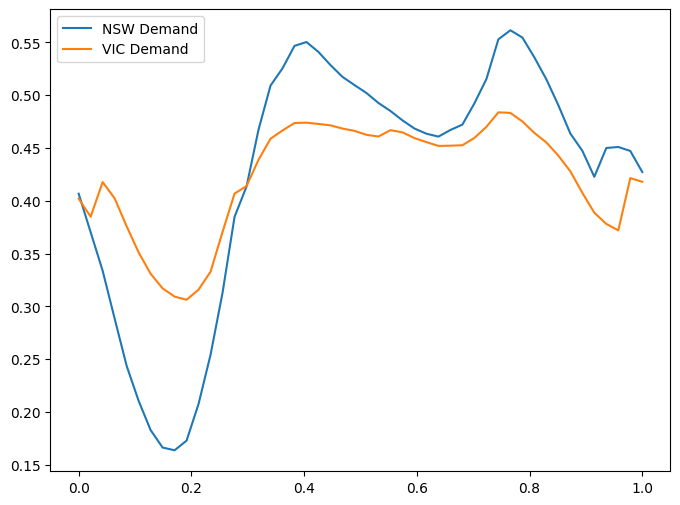

In [16]:
grouped = df_regular.groupby("period")[["nswprice", "vicprice", "nswdemand", "vicdemand"]].mean().reset_index()

plt.figure(figsize=(8,6))

plt.plot(grouped["period"], grouped["nswprice"], label="NSW Price")
plt.plot(grouped["period"], grouped["vicprice"], label="VIC Price")

plt.legend()
plt.show()

plt.figure(figsize=(8,6))

plt.plot(grouped["period"], grouped["nswdemand"], label="NSW Demand")
plt.plot(grouped["period"], grouped["vicdemand"], label="VIC Demand")

plt.legend()
plt.show()

# Irregular Dataset

Printing the head of the dataset

In [79]:
print(df_irregular.columns)

Index(['epoch time', 'date & time', 'smell value', 'skewed latitude',
       'skewed longitude', 'zipcode', 'smell description', 'symptoms',
       'additional comments'],
      dtype='object')


In [86]:
df_regular = df_irregular.copy()

In [87]:
df_regular["date & time"] = pd.to_datetime(df_regular["date & time"], utc=True)
df_regular = df_regular.set_index("date & time").sort_index()

In [88]:
aggregation = df_regular.resample("1h").agg(count = ("smell value", "size"), mean_smell = ("smell value", "mean"))

aggregation["count"] = aggregation["count"].fillna(0)
aggregation["mean_smell"] = aggregation["mean_smell"].fillna(0)

In [91]:
aggregation["log count"] = np.log1p(aggregation["count"])
aggregation["signal"] = aggregation["mean_smell"] * aggregation["log count"]

In [92]:
aggregation["smoothed"] = (aggregation["signal"].rolling(window=6, center=True)).mean()

In [102]:
df_regular.groupby([pd.Grouper(freq="1h"), "zipcode"]).size()

date & time                zipcode
2019-12-31 23:00:00+00:00  15237      1
2020-01-01 03:00:00+00:00  15217      1
2020-01-01 04:00:00+00:00  15110      1
2020-01-01 05:00:00+00:00  15037      1
2020-01-01 12:00:00+00:00  15037      1
                                     ..
2025-12-29 18:00:00+00:00  15202      1
2025-12-29 19:00:00+00:00  15209      1
2025-12-31 09:00:00+00:00  15212      1
2025-12-31 14:00:00+00:00  15211      1
2025-12-31 19:00:00+00:00  15104      1
Length: 58978, dtype: int64

In [94]:
print(aggregation.head())

                           count  mean_smell  log count    signal  smoothed
date & time                                                                
2019-12-31 23:00:00+00:00      1         3.0   0.693147  2.079442       NaN
2020-01-01 00:00:00+00:00      0         0.0   0.000000  0.000000       NaN
2020-01-01 01:00:00+00:00      0         0.0   0.000000  0.000000       NaN
2020-01-01 02:00:00+00:00      0         0.0   0.000000  0.000000  1.039721
2020-01-01 03:00:00+00:00      1         3.0   0.693147  2.079442  1.039721


In [103]:
irregular_count = len(df_irregular)
print("Irregular (raw) number of reports:", irregular_count)

Irregular (raw) number of reports: 75251


In [104]:
count=("smell value", "size")

regular_count = aggregation["count"].sum()
print("Regular (resampled total reports):", regular_count)

Regular (resampled total reports): 75251


## Visualizing the data

Different plots of the data, based on location and comments a day:

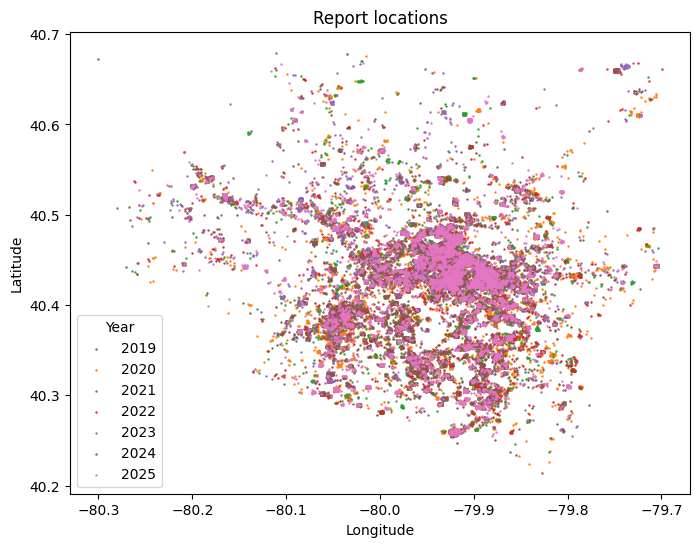

In [47]:
plt.figure(figsize=(8,6))

for i in df_regular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

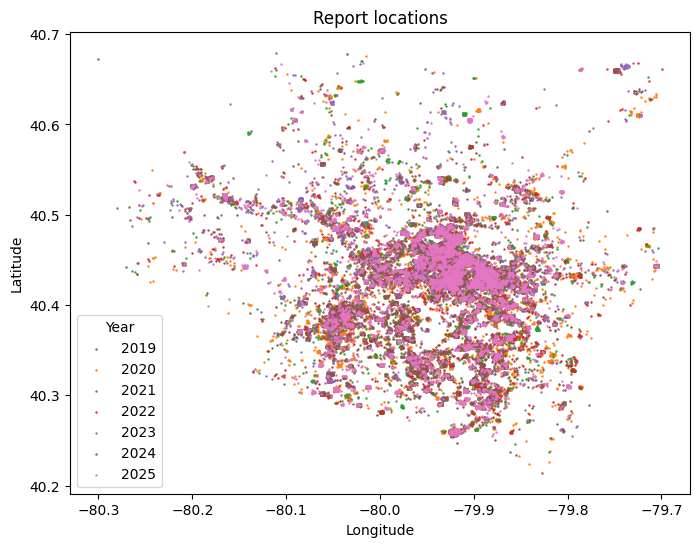

In [32]:
plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

In [96]:
print(df_regular.columns)

Index(['epoch time', 'smell value', 'skewed latitude', 'skewed longitude',
       'zipcode', 'smell description', 'symptoms', 'additional comments'],
      dtype='object')


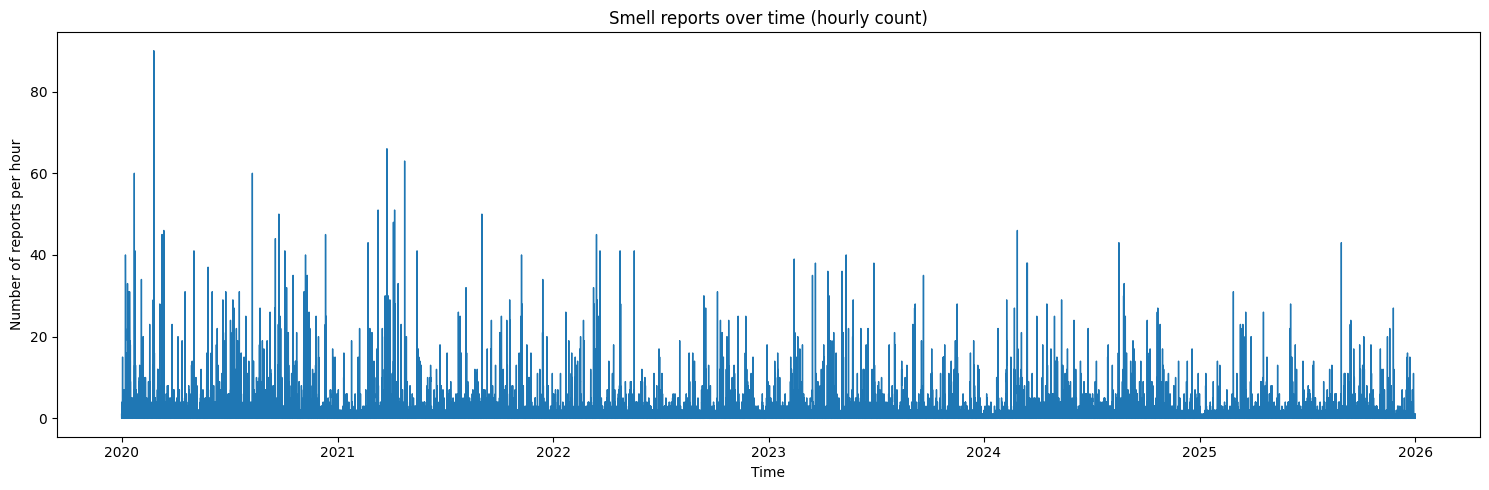

In [98]:
plt.figure(figsize=(15,5))
plt.plot(aggregation.index, aggregation["count"], linewidth=1)

plt.xlabel("Time")
plt.ylabel("Number of reports per hour")
plt.title("Smell reports over time (hourly count)")
plt.tight_layout()
plt.show()

# Textual processing

The primarly method will be a TF-IDF. When the context given by this method is not sufficient we will use embeddings instead.

In [ ]:
df_irregular["smell description"] = df_irregular["smell description"].str.lower()
df_irregular["symptoms"] = df_irregular["symptoms"].str.lower()
df_irregular["additional comments"] = df_irregular["additional comments"].str.lower()

<b>TF-IDF for smell description</b>:

In [ ]:
tfidf_desc = TfidfVectorizer(stop_words="english", max_features=500)

X_desc = tfidf_desc.fit_transform(df_irregular["smell description"].fillna(""))

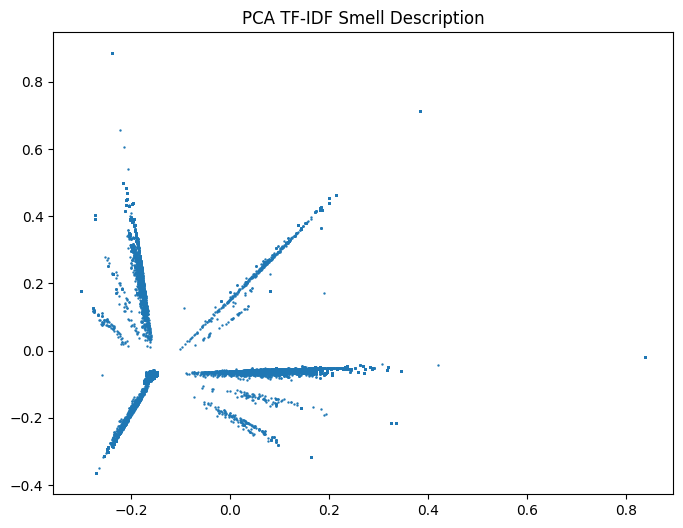

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_desc.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Smell Description")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for symptoms</b>:

In [ ]:
tfidf_symptoms = TfidfVectorizer(stop_words="english", max_features=500)

X_symptoms = tfidf_symptoms.fit_transform(df_irregular["symptoms"].fillna(""))

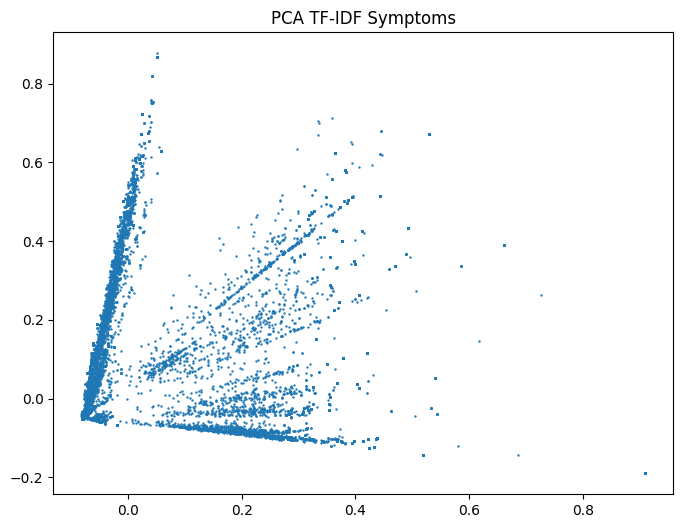

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_symptoms.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Symptoms")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for additional comments:</b>:

In [ ]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_comments = tfidf_comments.fit_transform(df_irregular["additional comments"].fillna(""))

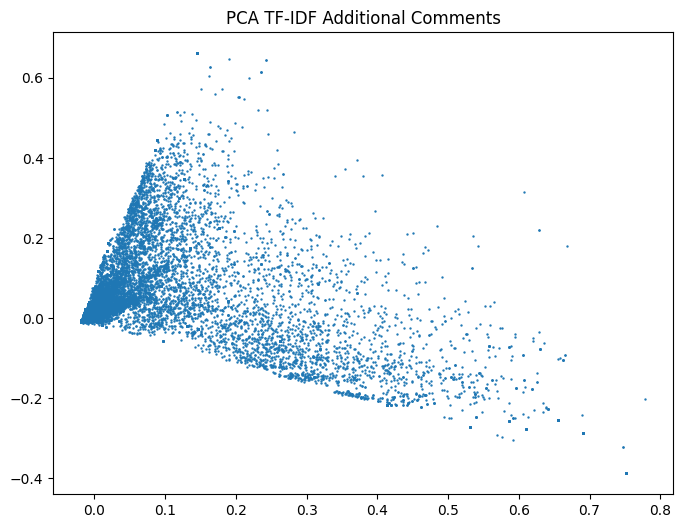

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_comments.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Additional Comments")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF combined:</b>:

Combining the three text fields into one:

In [ ]:
df_irregular["combined"] = df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna("")

In [ ]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_combined= tfidf_comments.fit_transform(df_irregular["combined"].fillna(""))

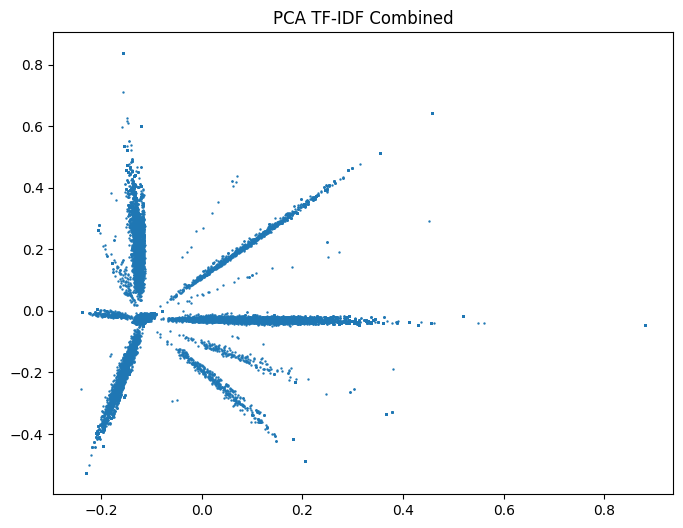

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

## Using Embeddings

The plot above shows that the TF-IDF might be too simple. We analyze that there are many spokes, which means that many points are in the same direction. The model is too simple to get proper meaning out of it. A better options will be embeddings.

In [ ]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
embeddings = model.encode(df_irregular["combined"].fillna("").tolist())

In [ ]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

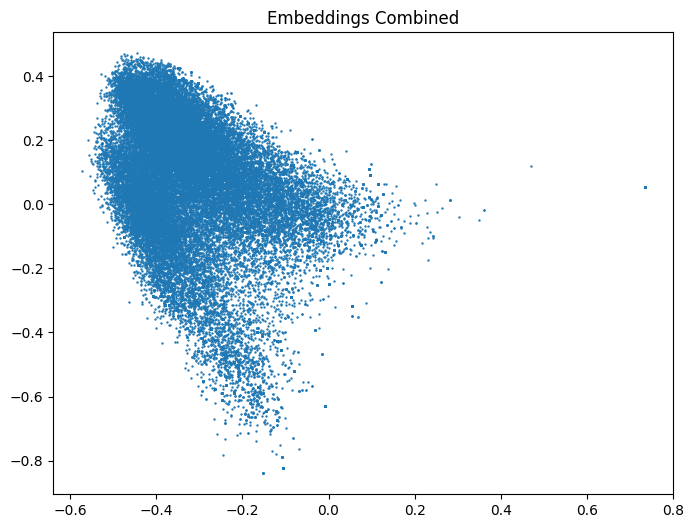

In [ ]:
plt.figure(figsize=(8,6))
plt.title("Embeddings Combined")
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], s=0.5)

# MMD on regular dataset